First 5 Rows:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_wor

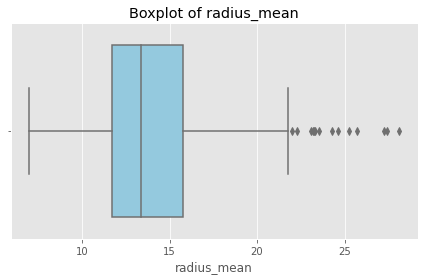

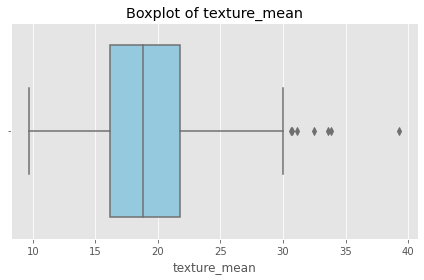

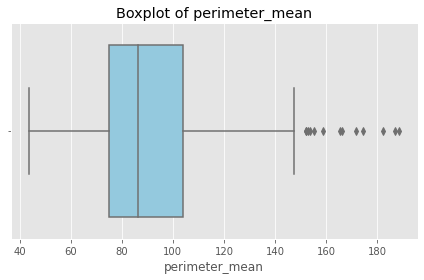

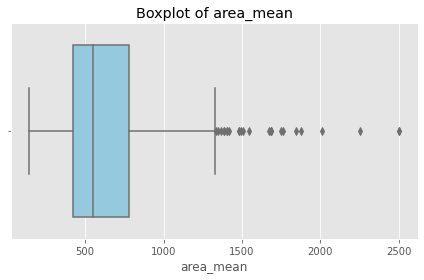

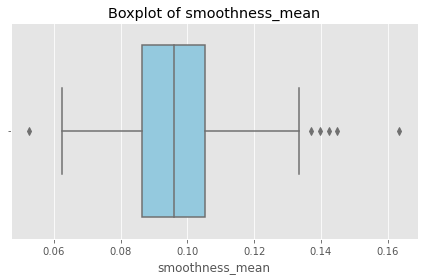

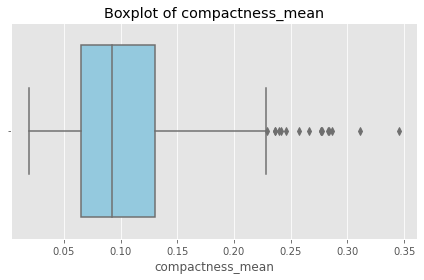

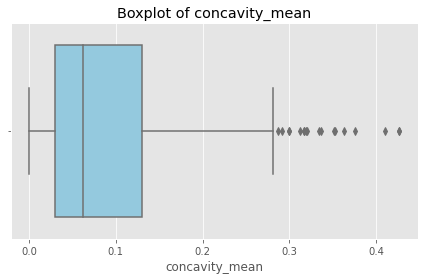

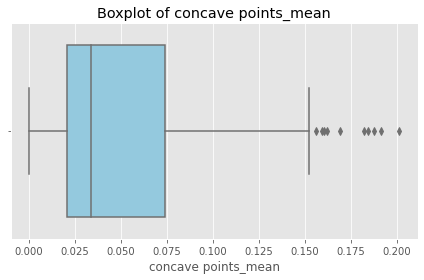

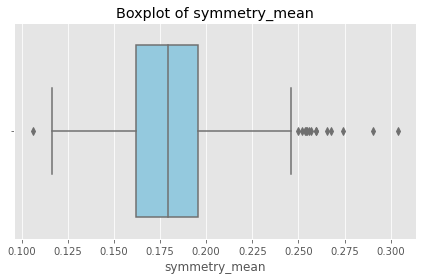

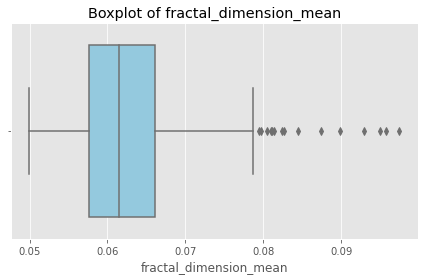

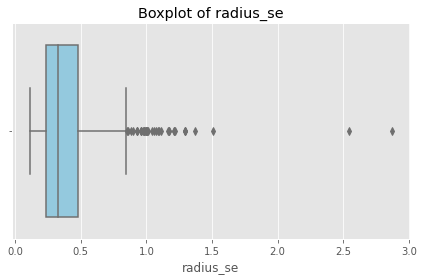

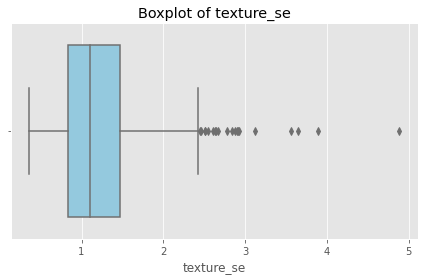

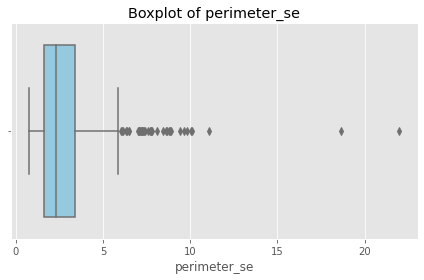

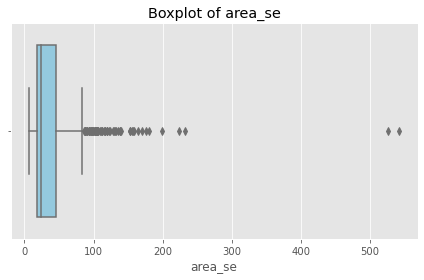

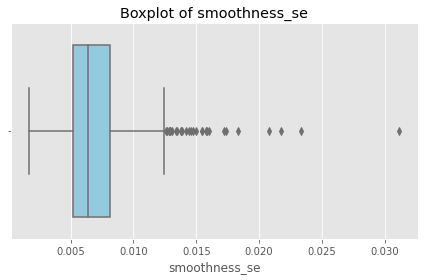

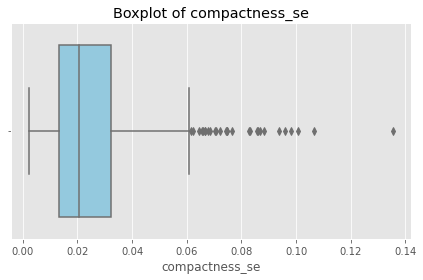

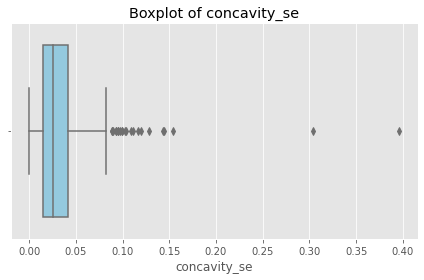

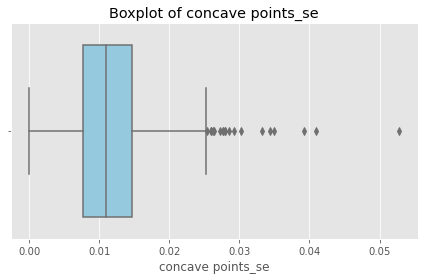

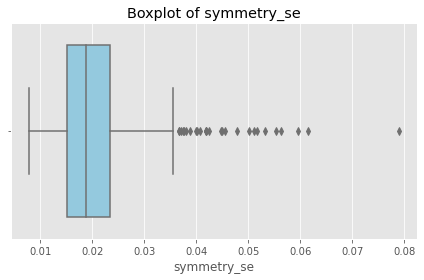

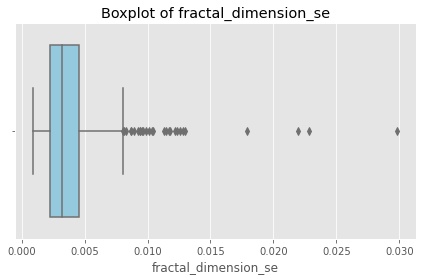

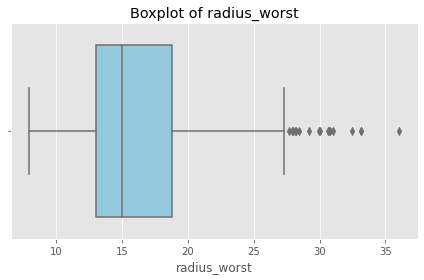

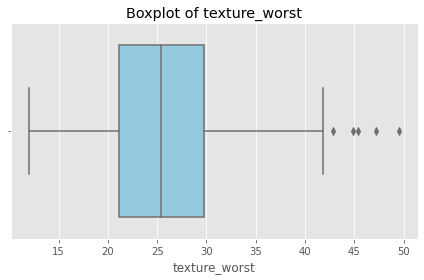

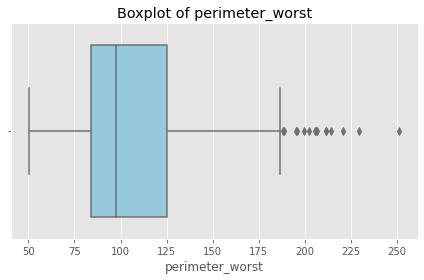

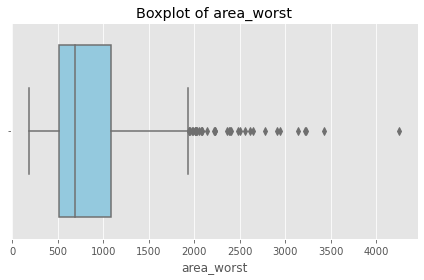

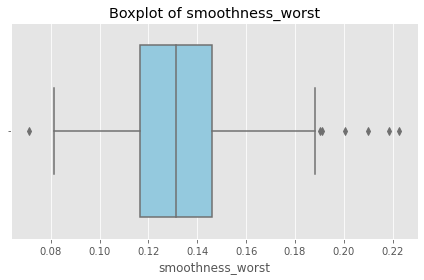

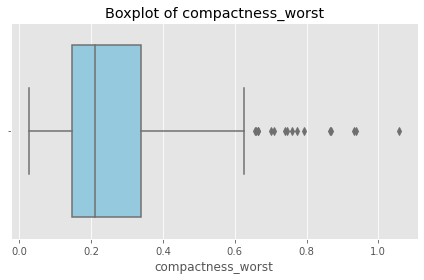

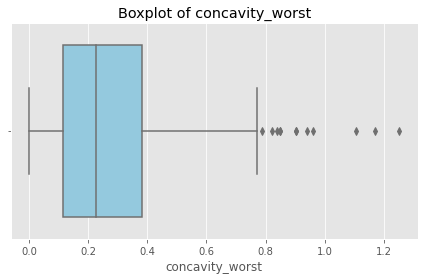

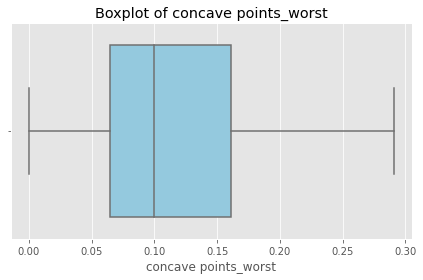

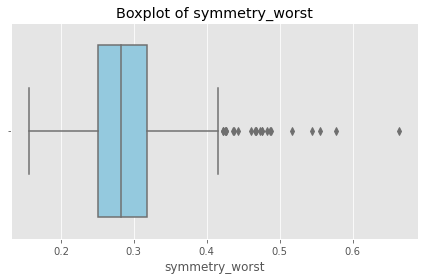

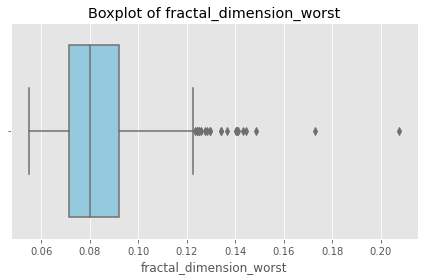

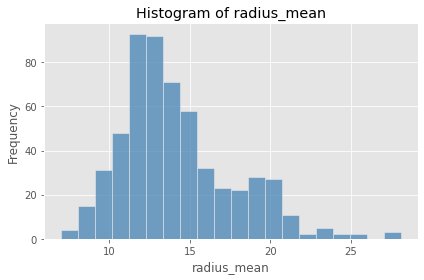

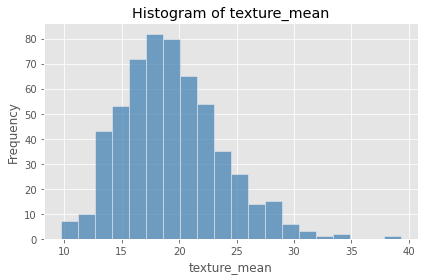

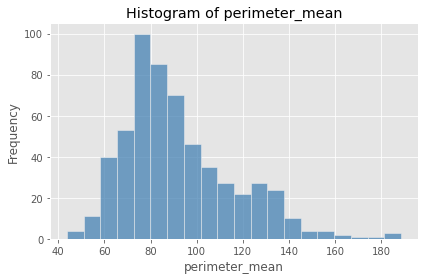

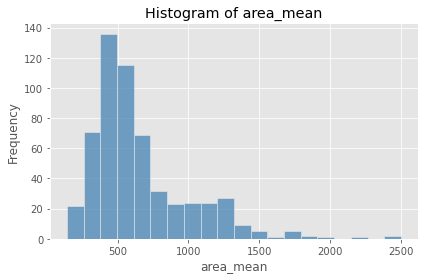

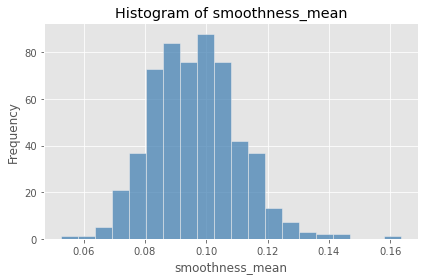

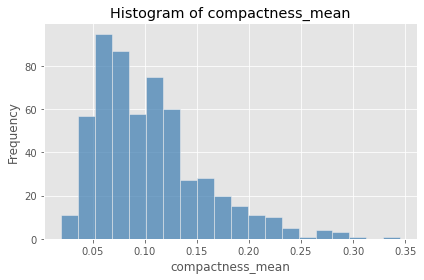

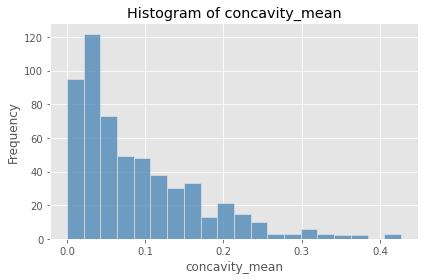

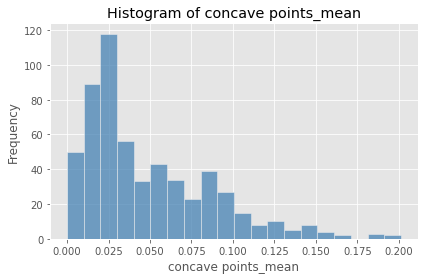

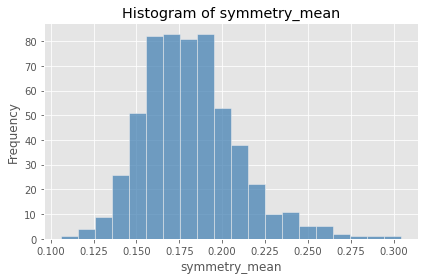

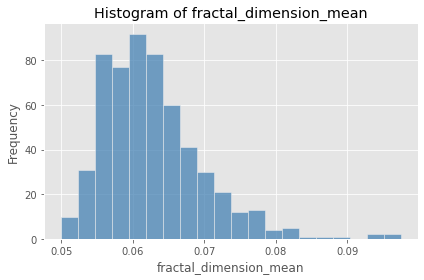

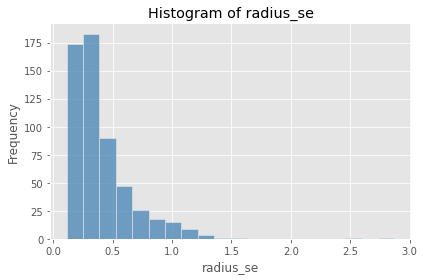

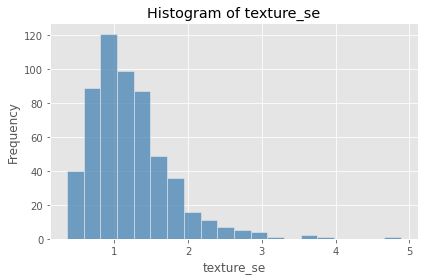

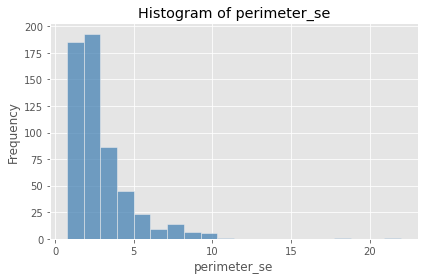

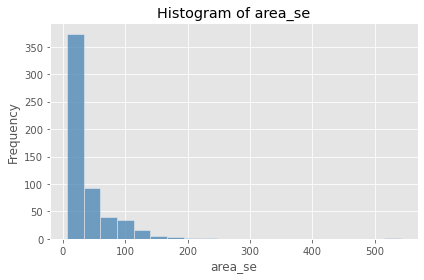

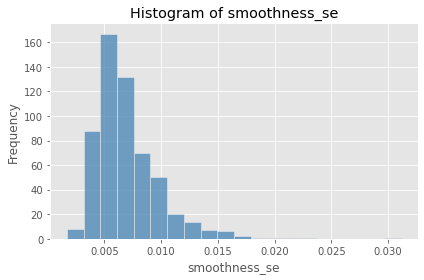

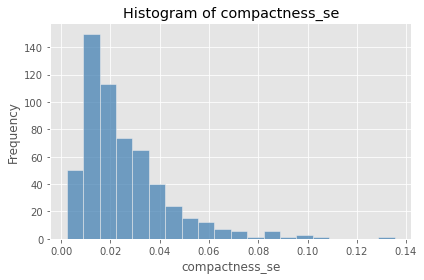

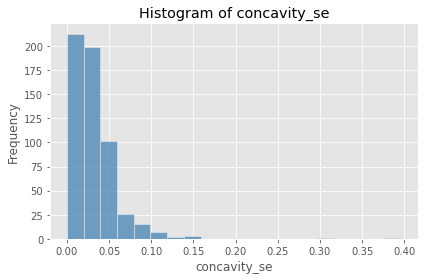

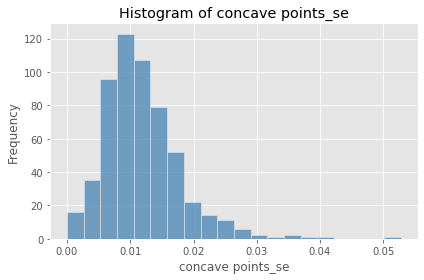

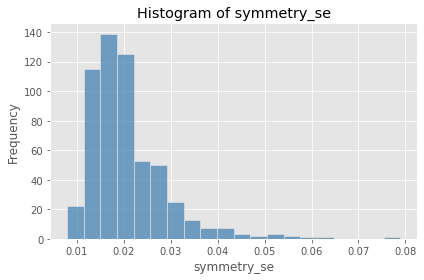

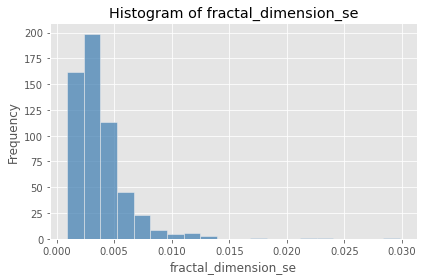

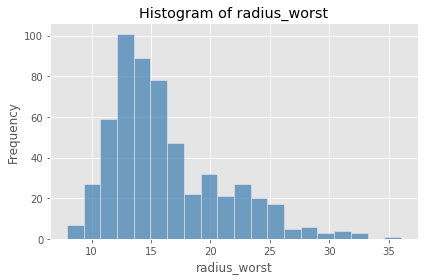

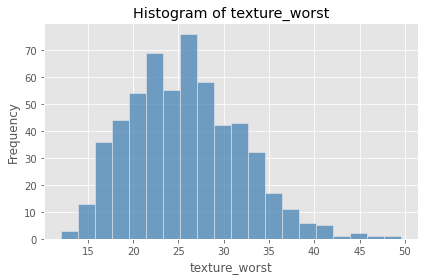

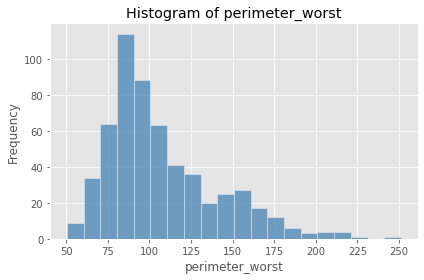

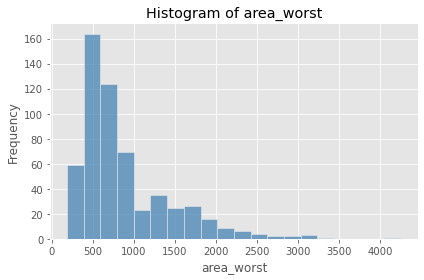

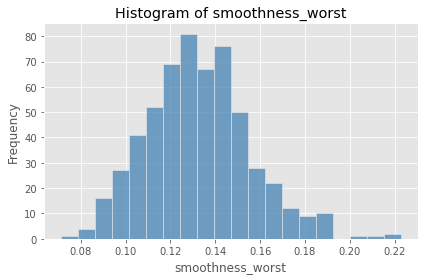

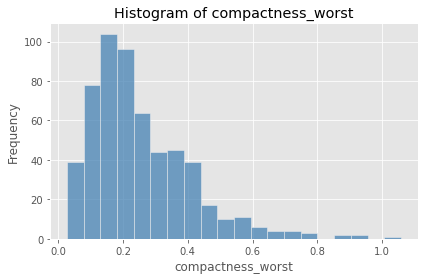

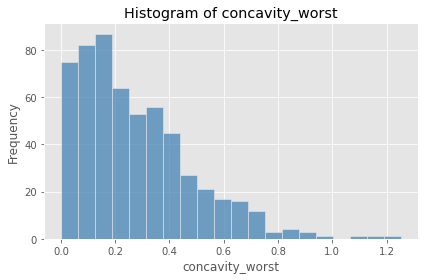

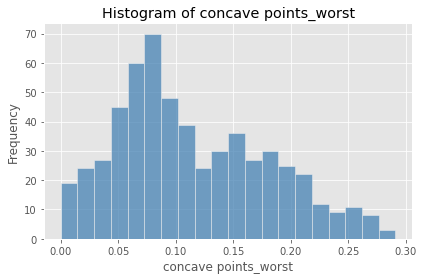

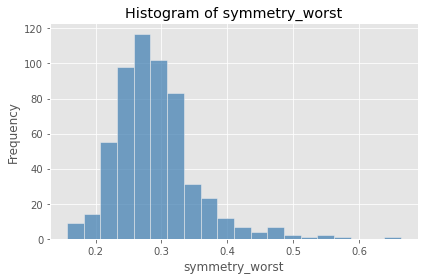

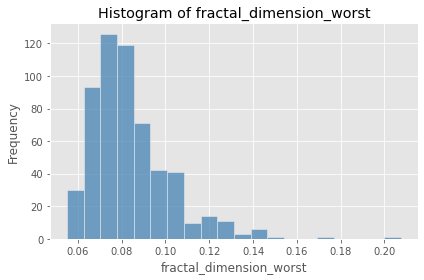

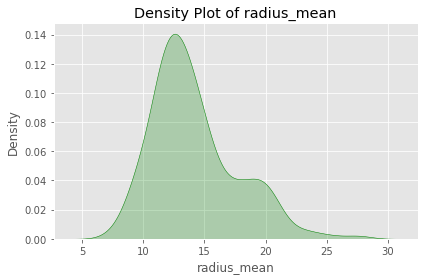

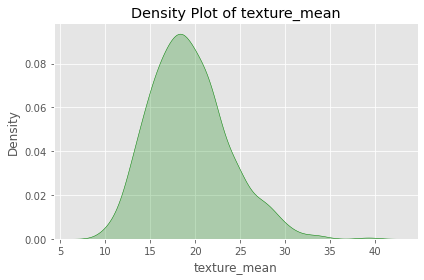

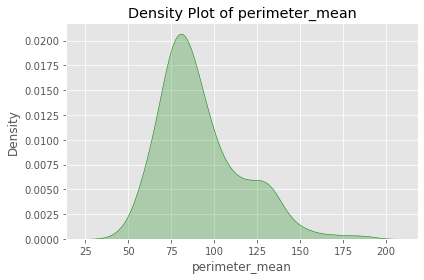

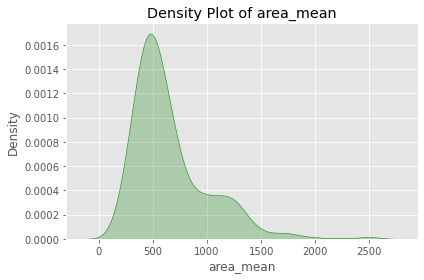

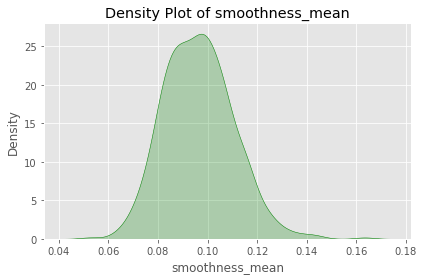

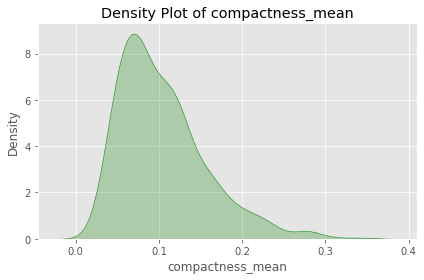

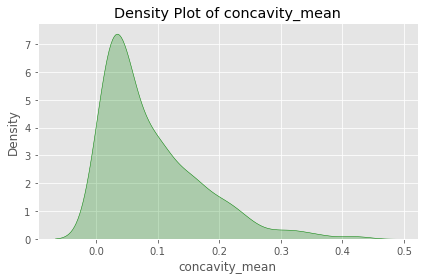

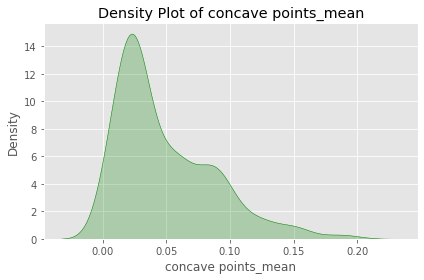

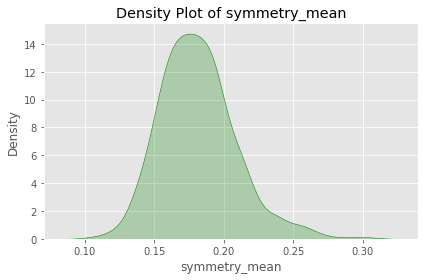

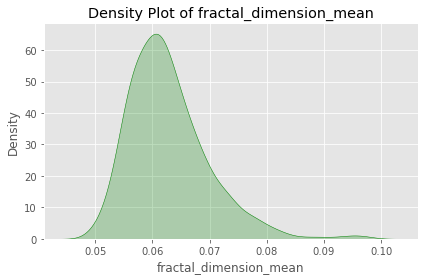

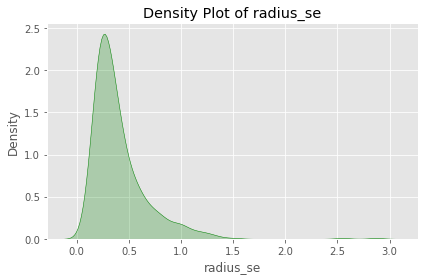

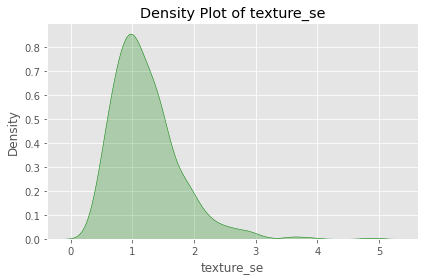

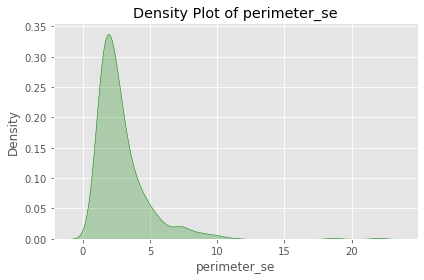

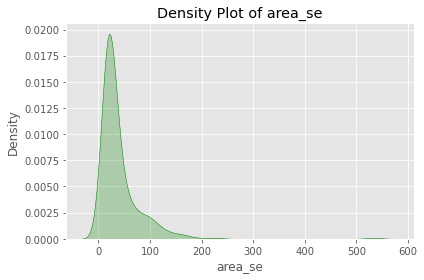

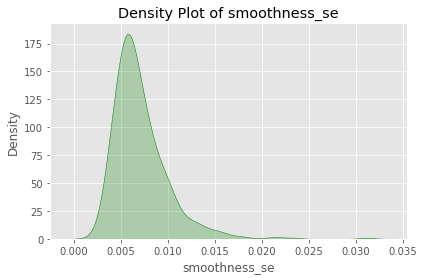

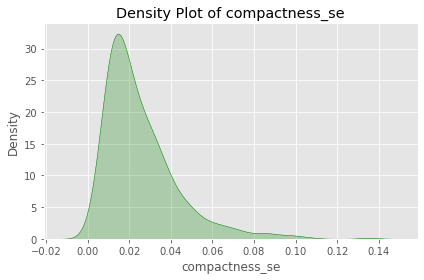

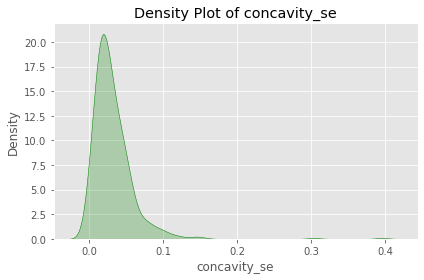

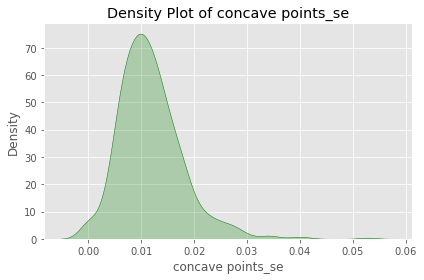

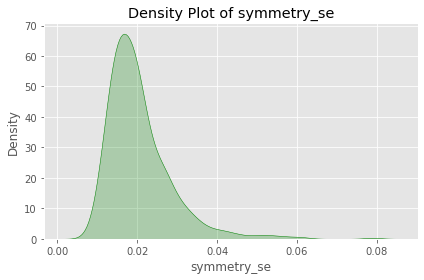

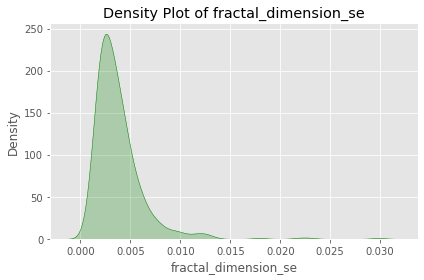

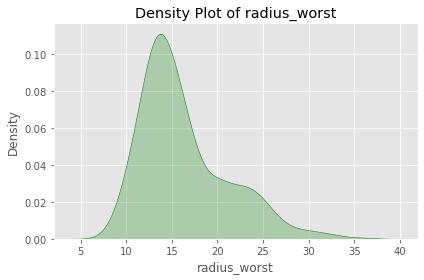

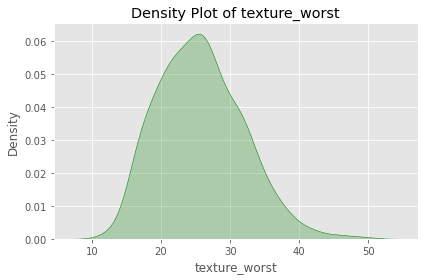

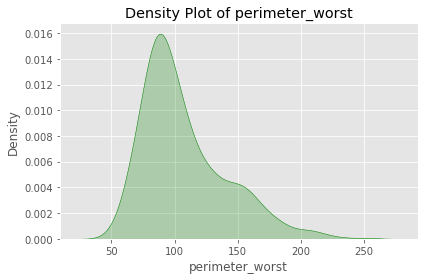

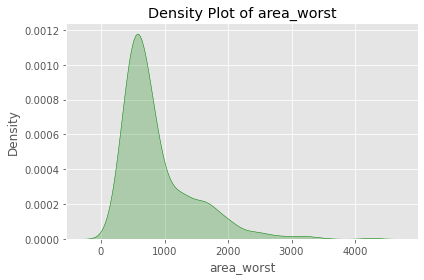

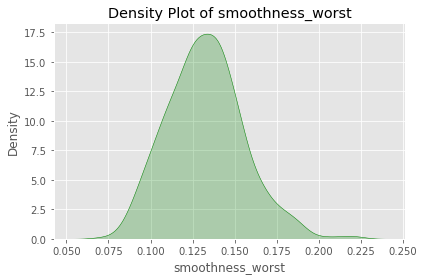

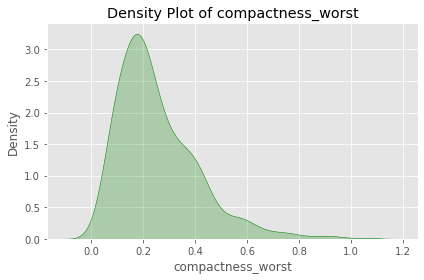

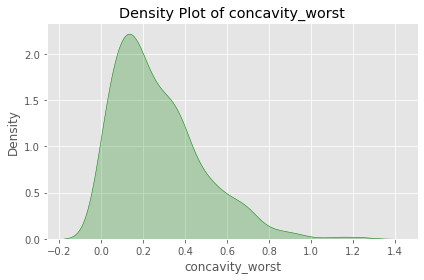

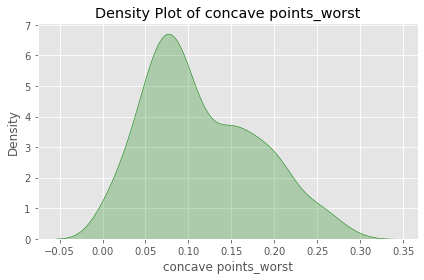

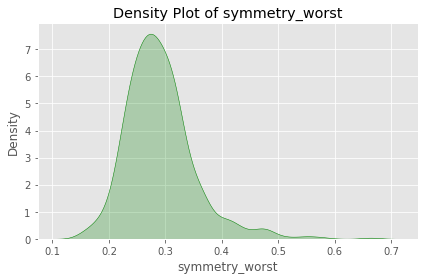

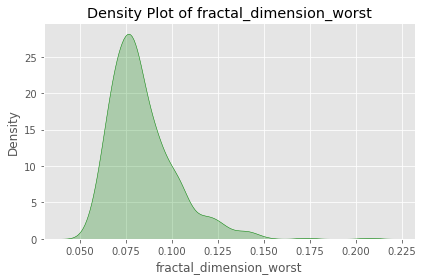

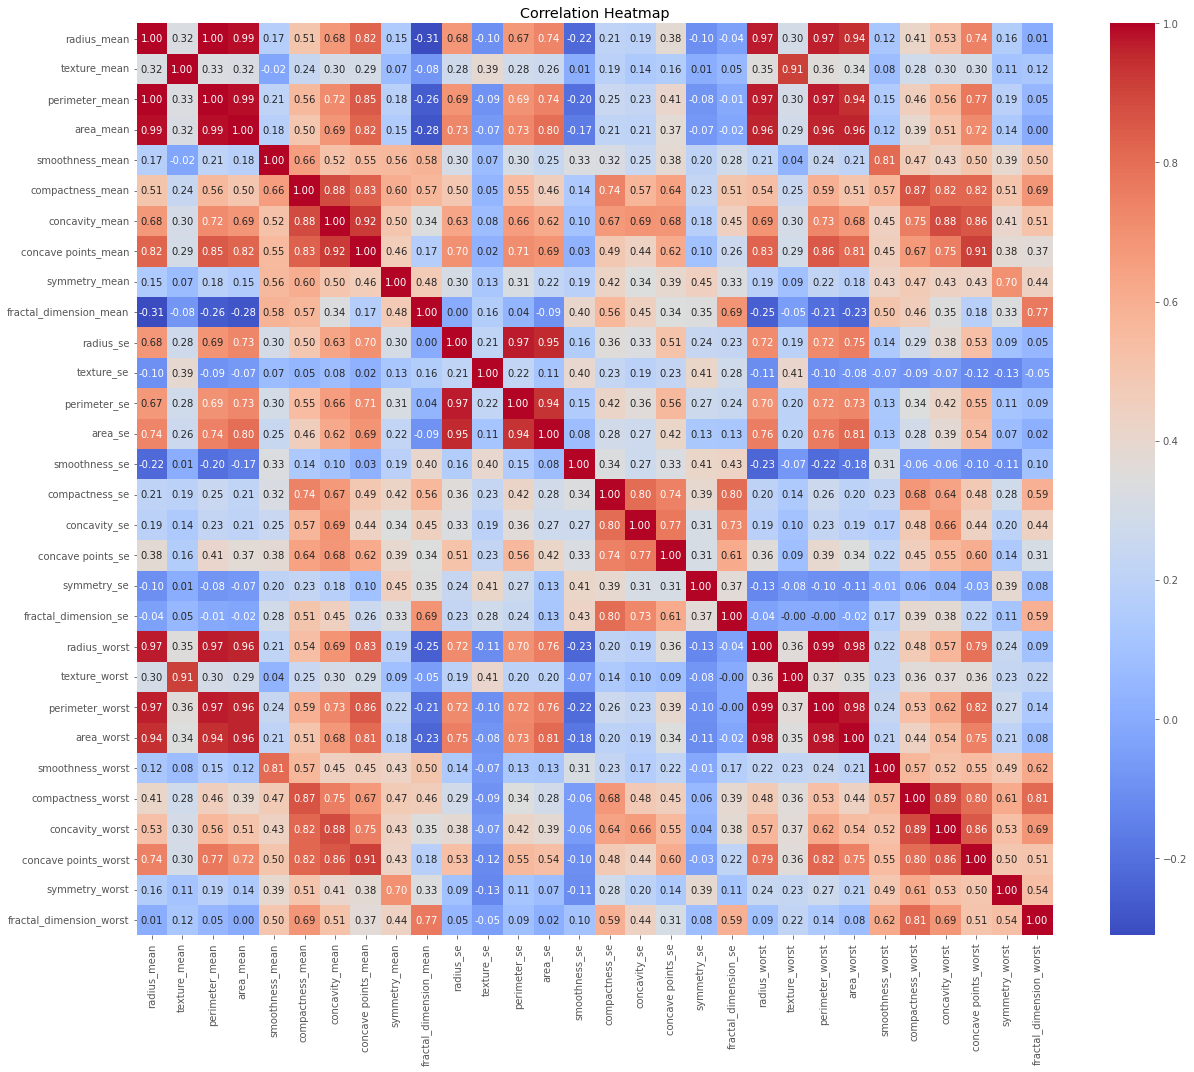

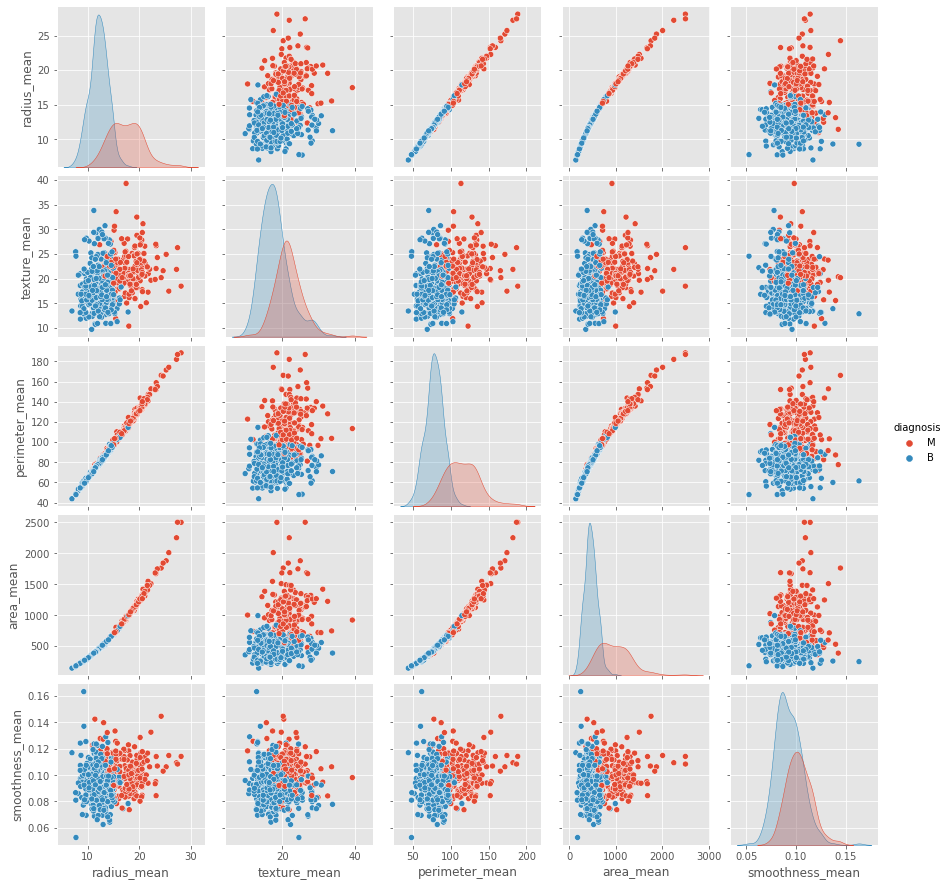

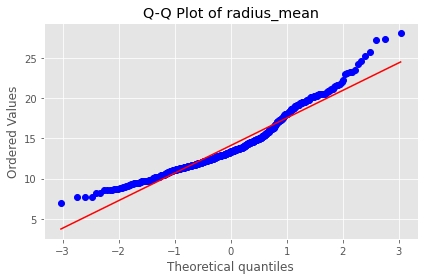

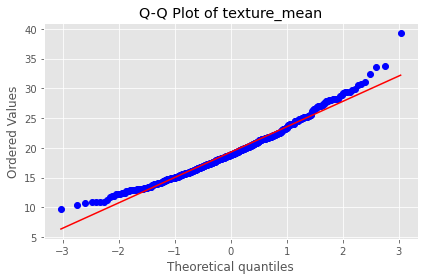

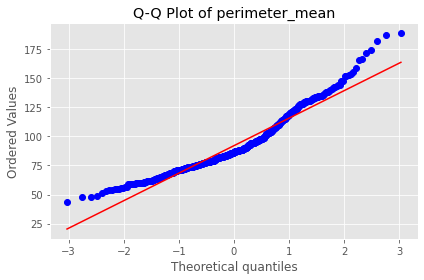

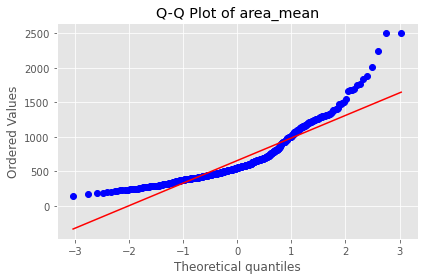

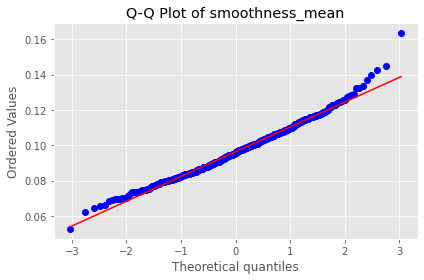

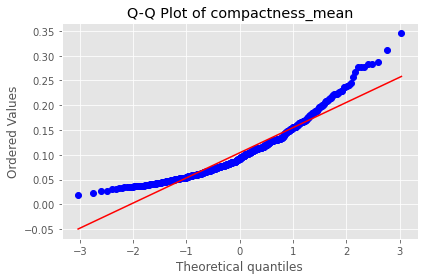

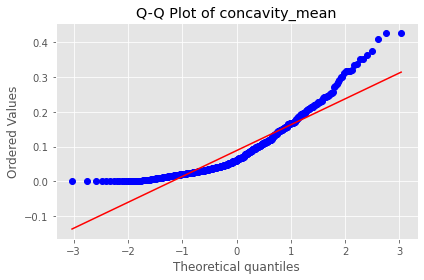

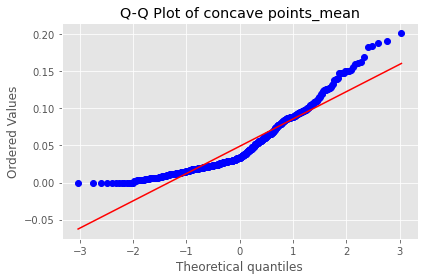

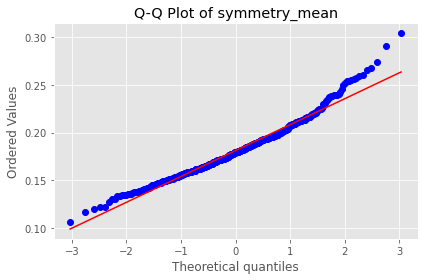

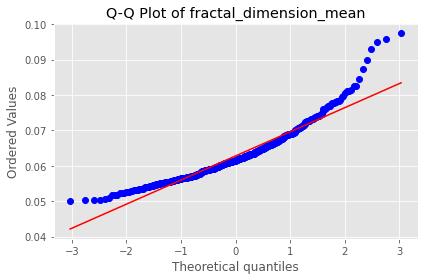

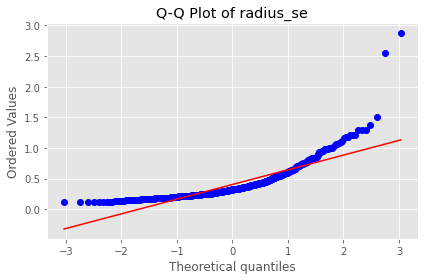

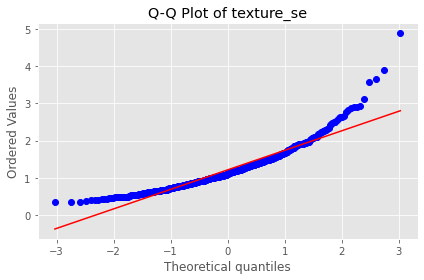

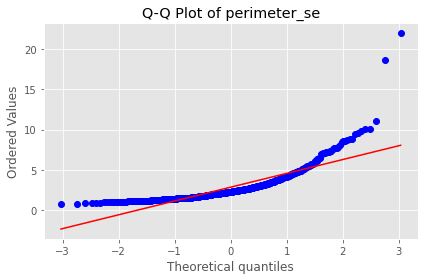

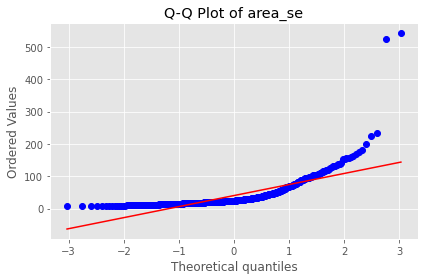

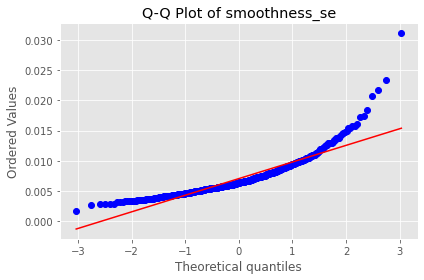

In [ ]:
#!/usr/bin/env python
# coding: utf-8

# In[2]:


# Install packages (Run once in Jupyter/Colab)
get_ipython().system('pip install pandas numpy scipy matplotlib seaborn')

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import trim_mean, median_abs_deviation
from scipy.stats import probplot

# Plot style
plt.style.use('ggplot')

# ==========================
# LOAD CANCER DATASET
# ==========================
df = pd.read_csv("Cancer_Data.csv")

# Display first 5 rows
print("First 5 Rows:")
print(df.head())

# Display dataset information
print("\nDataset Info:")
print(df.info())

# Remove unnecessary columns if present
drop_cols = ['id', 'Unnamed: 32']
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

# Display diagnosis count
if 'diagnosis' in df.columns:
    print("\nDiagnosis Distribution:")
    print(df['diagnosis'].value_counts())

# Select only numerical columns
num_df = df.select_dtypes(include=np.number)

print("\nNumerical Columns:")
print(num_df.columns)

# -------------------------------
# DESCRIPTIVE STATISTICS
# -------------------------------
print("\n========== DESCRIPTIVE STATISTICS ==========\n")

for col in num_df.columns:
    data = num_df[col].dropna()

    print(f"\n----- {col} -----")

    # Mean
    print("Mean:", data.mean())

    # Median
    print("Median:", data.median())

    # Trimmed Mean (10%)
    print("Trimmed Mean:", trim_mean(data, 0.10))

    # Weighted Mean
    weights = np.arange(1, len(data)+1)
    print("Weighted Mean:", np.average(data, weights=weights))

    # Range
    print("Range:", data.max() - data.min())

    # Variance
    print("Variance:", data.var())

    # Standard Deviation
    print("Standard Deviation:", data.std())

    # IQR
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    print("IQR:", IQR)

    # Median Absolute Deviation
    print("Median Absolute Deviation:", median_abs_deviation(data))

# -------------------------------
# VISUALIZATIONS
# -------------------------------

# 1. Boxplots
for col in num_df.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=num_df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

# 2. Histograms
for col in num_df.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(num_df[col], bins=20, color='steelblue')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# 3. Density Plots
for col in num_df.columns:
    plt.figure(figsize=(6,4))
    sns.kdeplot(num_df[col], fill=True, color='green')
    plt.title(f'Density Plot of {col}')
    plt.tight_layout()
    plt.show()

# 4. Correlation Heatmap
plt.figure(figsize=(18,15))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# 5. Pair Plot (using diagnosis as hue if available)
if 'diagnosis' in df.columns:
    sns.pairplot(df, vars=num_df.columns[:5], hue='diagnosis')
else:
    sns.pairplot(num_df.iloc[:, :5])

plt.show()

# 6. Q-Q Plots
for col in num_df.columns:
    plt.figure(figsize=(6,4))
    probplot(num_df[col].dropna(), dist="norm", plot=plt)
    plt.title(f'Q-Q Plot of {col}')
    plt.tight_layout()
    plt.show()

print("\nAnalysis Completed Successfully!")





# ======================================
# VISUALIZATIONS WITH OBSERVATIONS
# ======================================

from scipy.stats import probplot

# -------------------------------
# 1. BOXPLOT
# -------------------------------
for col in num_df.columns:

    plt.figure(figsize=(6,4))
    sns.boxplot(x=num_df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
    plt.show()

    data = num_df[col].dropna()

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = data[(data<lower) | (data>upper)]

    print("Observation:")
    if len(outliers)==0:
        print("• No significant outliers are present.\n")
    else:
        print(f"• {len(outliers)} outliers are present in the dataset.\n")


# -------------------------------
# 2. HISTOGRAM
# -------------------------------
for col in num_df.columns:

    plt.figure(figsize=(6,4))
    sns.histplot(num_df[col], bins=20, color='steelblue')
    plt.title(f'Histogram of {col}')
    plt.show()

    skew = num_df[col].skew()

    print("Observation:")
    if skew > 0.5:
        print("• Distribution is positively skewed.\n")
    elif skew < -0.5:
        print("• Distribution is negatively skewed.\n")
    else:
        print("• Distribution is approximately symmetric.\n")


# -------------------------------
# 3. DENSITY PLOT
# -------------------------------
for col in num_df.columns:

    plt.figure(figsize=(6,4))
    sns.kdeplot(num_df[col], fill=True, color='green')
    plt.title(f'Density Plot of {col}')
    plt.show()

    skew = num_df[col].skew()

    print("Observation:")
    if abs(skew)<0.5:
        print("• Density curve is approximately bell-shaped.\n")
    else:
        print("• Density curve is skewed.\n")


# -------------------------------
# 4. HEATMAP
# -------------------------------
plt.figure(figsize=(14,12))
corr = num_df.corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

print("Observation:")

strong = []

for i in range(len(corr.columns)):
    for j in range(i+1,len(corr.columns)):

        if abs(corr.iloc[i,j])>0.75:
            strong.append((corr.columns[i],
                           corr.columns[j],
                           corr.iloc[i,j]))

if len(strong)==0:
    print("• No strong correlations are observed.\n")
else:
    print("• Strong correlations observed between:\n")
    for a,b,c in strong:
        print(f"  {a} ↔ {b} : {c:.2f}")
    print()


# -------------------------------
# 5. PAIRPLOT
# -------------------------------
if 'diagnosis' in df.columns:
    sns.pairplot(df,
                 vars=num_df.columns[:5],
                 hue='diagnosis')
else:
    sns.pairplot(num_df.iloc[:,:5])

plt.show()

print("Observation:")
print("• Pair plot shows relationships among numerical variables.")
print("• Benign and Malignant samples tend to form separate clusters.")
print("• Positively sloped patterns indicate positive correlation.")
print("• Random scatter indicates weak correlation.\n")


# -------------------------------
# 6. Q-Q PLOT
# -------------------------------
for col in num_df.columns:

    plt.figure(figsize=(6,4))
    probplot(num_df[col].dropna(),
             dist="norm",
             plot=plt)

    plt.title(f'Q-Q Plot of {col}')
    plt.show()

    skew = num_df[col].skew()

    print("Observation:")

    if abs(skew)<0.5:
        print("• Points closely follow the straight line.")
        print("• Data is approximately normally distributed.\n")
    else:
        print("• Points deviate from the straight line.")
        print("• Data does not follow a normal distribution.\n")


# In[ ]:




